In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (9, 4)

In [2]:
from google.colab import files

#Loading Datasets
uploaded = files.upload()

Saving Arnold 001.xlsx to Arnold 001.xlsx
Saving Arnold 002.xlsx to Arnold 002.xlsx
Saving Arnold 003.xlsx to Arnold 003.xlsx
Saving Arnold 004.xlsx to Arnold 004.xlsx
Saving Arnold 005.xlsx to Arnold 005.xlsx
Saving Arnold 006.xlsx to Arnold 006.xlsx
Saving Arnold 007.xlsx to Arnold 007.xlsx
Saving Arnold 008.xlsx to Arnold 008.xlsx
Saving Arnold 009.xlsx to Arnold 009.xlsx
Saving Mendez 001.xlsx to Mendez 001.xlsx
Saving Mendez 002.xlsx to Mendez 002.xlsx
Saving Mendez 003.xlsx to Mendez 003.xlsx
Saving Mendez 004.xlsx to Mendez 004.xlsx
Saving Mendez 005.xlsx to Mendez 005.xlsx
Saving Shawn 001.xlsx to Shawn 001.xlsx


In [3]:
new_names = {
    'Case Number': 'CASE_NUMBER',
    'Provider Approving Name': 'PROVIDER_APPROVING_NAME',
    'Most Recent Approval Date (CST)' : 'APPROVAL_DATE'
}
file_list = sorted(glob.glob('*.xlsx'))
tables =[]

for file_name in file_list:
  one_file = pd.read_excel(file_name)
  one_file = one_file.rename(columns=new_names)
  tables.append(one_file)
  print(file_name, 'rows:', len(one_file))

df = pd.concat(tables, ignore_index=True)
print('\nTotal rows:', len(df))
df.head()

Arnold 001.xlsx rows: 3602
Arnold 002.xlsx rows: 3833
Arnold 003.xlsx rows: 5169
Arnold 004.xlsx rows: 4862
Arnold 005.xlsx rows: 5448
Arnold 006.xlsx rows: 5998
Arnold 007.xlsx rows: 5209
Arnold 008.xlsx rows: 4218
Arnold 009.xlsx rows: 4307
Mendez 001.xlsx rows: 3282
Mendez 002.xlsx rows: 3825
Mendez 003.xlsx rows: 3483
Mendez 004.xlsx rows: 3931
Mendez 005.xlsx rows: 2948
Shawn 001.xlsx rows: 4115

Total rows: 64230


,CASE_NUMBER,PROVIDER_APPROVING_NAME,APPROVAL_DATE
0,C327bc5ef27d75,Gary arnold,2019-02-19 10:02:49
1,C9cc8268c0d75f,Gary arnold,2019-02-19 13:45:44
2,C484d8e6d0448b,Gary arnold,2019-02-22 06:21:49
3,C2f3a937707f28,Gary arnold,2019-02-26 11:21:24
4,C294dc275d81c5,Gary arnold,2019-02-20 12:13:51


# Data Preparation

In [4]:
#Make the approval date a real datetime
df['APPROVAL_DATE'] = pd.to_datetime(df['APPROVAL_DATE'])

#Fix the technician name ('Gary arnold' -> 'Gary Arnold')
df['Technician'] = df['PROVIDER_APPROVING_NAME'].str.strip().str.title()

df = df[['CASE_NUMBER', 'Technician', 'APPROVAL_DATE']]

print('Missing values:')
print(df.isnull().sum())

Missing values:
CASE_NUMBER      0
Technician       0
APPROVAL_DATE    0
dtype: int64


In [5]:
#Drop missing values and exact duplicate approval
rows_before = len(df)
df= df.dropna()
df = df.drop_duplicates()
print('Rows removed:', rows_before - len(df))

#Sort by technician and time - this is required before measuring gaps
df = df.sort_values(['Technician', 'APPROVAL_DATE'])
df = df.reset_index(drop=True)

print('Final shape:', df.shape)
df.head()

Rows removed: 0
Final shape: (64230, 3)


,CASE_NUMBER,Technician,APPROVAL_DATE
0,C5c8bc0c2dbb6a,Gary Arnold,2019-02-01 10:04:27
1,C1188f1e1dc09f,Gary Arnold,2019-02-01 10:04:31
2,C3d7e298e6f187,Gary Arnold,2019-02-01 10:04:35
3,Cdbc65218dc612,Gary Arnold,2019-02-01 10:04:39
4,C1604-CERVAM-646381,Gary Arnold,2019-02-01 10:04:44


In [6]:
# How much data does each technician have?
coverage = df.groupby('Technician')['APPROVAL_DATE'].agg(['count', 'min', 'max'])
coverage.columns = ['approvals', 'first_approval', 'last_approval']
print(coverage)

#Approvals per month
month_counts = pd.crosstab(df['APPROVAL_DATE'].dt.to_period('M'), df['Technician'])
print('\nApprovals per month (the months are not continuous):')
print(month_counts)

             approvals      first_approval       last_approval
Technician                                                    
Gary Arnold      42646 2019-02-01 10:04:27 2021-09-30 17:01:34
Juan Mendez      17469 2019-02-01 09:15:47 2019-11-30 21:12:44
Matt Shawn        4115 2019-02-01 08:18:17 2019-02-28 17:05:42

Approvals per month (the months are not continuous):
Technician     Gary Arnold  Juan Mendez  Matt Shawn
APPROVAL_DATE                                      
2019-02               3602         3282        4115
2019-03               3833         3825           0
2019-04                  0         3483           0
2019-05                  0         3931           0
2019-11               5169         2948           0
2021-01               4862            0           0
2021-02               5448            0           0
2021-03               5998            0           0
2021-06               5209            0           0
2021-08               4218            0           0
2021-09

# Time-Based

In [7]:
#Gap in seconds since the technician's previous approval
df['duration_second'] = df.groupby('Technician')['APPROVAL_DATE'].diff().dt.total_seconds()

#Date and time feature
df['date'] = df['APPROVAL_DATE'].dt.date
df['hour'] = df['APPROVAL_DATE'].dt.hour
df['weekday'] = df['APPROVAL_DATE'].dt.day_name()
df['month'] = df['APPROVAL_DATE'].dt.to_period('M').astype(str)
df['is_weekend'] = df['APPROVAL_DATE'].dt.dayofweek >= 5

#Keep the gap only when the previous approval was on the same day
previous_date = df.groupby('Technician')['date'].shift()
df['same_day'] = previous_date == df['date']

df['duration_sameday'] = df['duration_second'].where(df['same_day'])

# Add payout period based on policy change
policy_change = pd.Timestamp('2020-06-01') # Adjusted to June 2020 as per labels

def payout_label (date):
  if date < policy_change:
    return 'Pre-June2020 ($50)'
  else:
    return 'Post-June2020 ($17)'

df['payout_period'] = df['APPROVAL_DATE'].apply(payout_label)

df.head()

,CASE_NUMBER,Technician,APPROVAL_DATE,duration_second,date,hour,weekday,month,is_weekend,same_day,duration_sameday,payout_period
0,C5c8bc0c2dbb6a,Gary Arnold,2019-02-01 10:04:27,NaN,2019-02-01,10,Friday,2019-02,False,False,NaN,Pre-June2020 ($50)
1,C1188f1e1dc09f,Gary Arnold,2019-02-01 10:04:31,4.0,2019-02-01,10,Friday,2019-02,False,True,4.0,Pre-June2020 ($50)
2,C3d7e298e6f187,Gary Arnold,2019-02-01 10:04:35,4.0,2019-02-01,10,Friday,2019-02,False,True,4.0,Pre-June2020 ($50)
3,Cdbc65218dc612,Gary Arnold,2019-02-01 10:04:39,4.0,2019-02-01,10,Friday,2019-02,False,True,4.0,Pre-June2020 ($50)
4,C1604-CERVAM-646381,Gary Arnold,2019-02-01 10:04:44,5.0,2019-02-01,10,Friday,2019-02,False,True,5.0,Pre-June2020 ($50)


In [8]:

# This cell should only display the cross-tabulation.
print(pd.crosstab(df['Technician'], df['payout_period']))

payout_period  Post-June2020 ($17)  Pre-June2020 ($50)
Technician                                            
Gary Arnold                  30042               12604
Juan Mendez                      0               17469
Matt Shawn                       0                4115


In [9]:
#Blocks: a gap of 10 minutes (or a new day) starts a new review session
block_gap = 10 * 60

df['new_block'] = (df['duration_second'].isnull()) | (~df['same_day']) | (df['duration_second'] >= block_gap)
df['block_id'] = df.groupby('Technician')['new_block'].cumsum()

#Gap only when we are inside a block
df['duration_inblock'] = df['duration_second'].where(df['new_block'] == False)

#List of technicians, used throughout the notebook
techs = sorted(df['Technician'].unique())
print('Technicians:', techs)
print('Blocks per technician:')
print(df.groupby('Technician')['block_id'].nunique())

Technicians: ['Gary Arnold', 'Juan Mendez', 'Matt Shawn']
Blocks per technician:
Technician
Gary Arnold    1556
Juan Mendez    1076
Matt Shawn      177
Name: block_id, dtype: int64


# Approval Duration per Case

In [10]:
#Summary of the same-day gap, in seconds
Summary = df.groupby('Technician')['duration_sameday'].describe()
print('Same-day gap in seconds:')
print(Summary.round(2))

Same-day gap in seconds:
               count    mean      std  min   25%   50%   75%      max
Technician                                                           
Gary Arnold  42383.0  187.95  1720.28  0.0   3.0   4.0   8.0  74800.0
Juan Mendez  17321.0  293.14  1671.67  0.0  21.0  29.0  49.0  55907.0
Matt Shawn    4087.0  250.11  1812.17  0.0   5.0   6.0  18.0  31857.0


In [11]:
#Same numbers in minutes to compare to industry standard
minutes = df.groupby('Technician')['duration_sameday'].agg(['mean','median']) /60
minutes.columns = ['mean_minutes', 'median_minutes']
print(minutes.round(2))

             mean_minutes  median_minutes
Technician                               
Gary Arnold          3.13            0.07
Juan Mendez          4.89            0.48
Matt Shawn           4.17            0.10


# Fast-Approval Analysis

In [12]:
review_thresholds = [0,2,5,10,30,60]
fast_pace =[]

for tech in techs:
  gaps = df.loc[df['Technician']== tech, 'duration_sameday'].dropna()
  row = {'Technician': tech, 'n_gaps': len(gaps)}
  for t in review_thresholds:
    percent = (gaps <= t).mean() * 100
    row[str(t) + 's or less (%)'] = round(percent, 2)
  fast_pace.append(row)

fast_approval_table = pd.DataFrame(fast_pace).set_index('Technician')
print(fast_approval_table)

             n_gaps  0s or less (%)  2s or less (%)  5s or less (%)  10s or less (%)  30s or less (%)  60s or less (%)
Technician                                                                                                            
Gary Arnold   42383            0.64           11.19           65.78            78.63            87.36            92.24
Juan Mendez   17321            0.08            0.34            1.63             6.70            52.91            81.27
Matt Shawn     4087            0.46            1.91           35.53            68.97            81.40            88.01


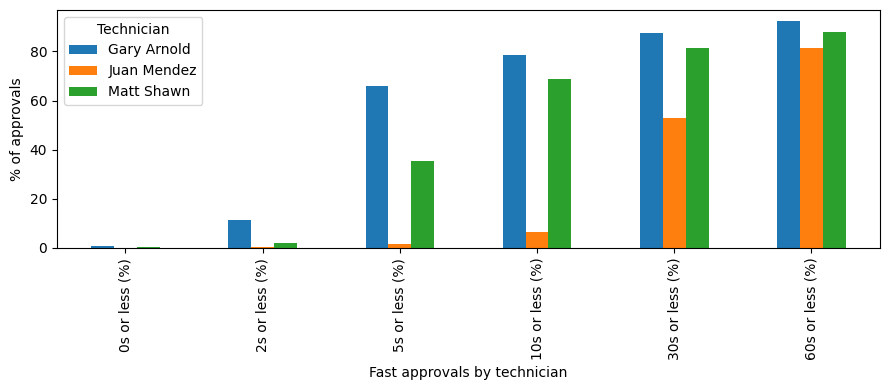

In [13]:
plot_data  = fast_approval_table.drop(columns='n_gaps')
plot_data.T.plot(kind ='bar')
plt.ylabel('% of approvals')
plt.xlabel('Fast approvals by technician')
plt.tight_layout()
plt.show()

# Quick Succession & Same Minute/Second

In [14]:
skewness_table = pd.DataFrame({
    'skewness' : df.groupby('Technician')['duration_sameday'].skew(),
    'mean_seconds': df.groupby('Technician')['duration_sameday'].mean(),
    'median_seconds': df.groupby('Technician')['duration_sameday'].median()
})
skewness_table['mean_divided_by_median'] = skewness_table['mean_seconds'] / skewness_table['median_seconds']
print(skewness_table.round(2))

             skewness  mean_seconds  median_seconds  mean_divided_by_median
Technician                                                                 
Gary Arnold     17.37        187.95             4.0                   46.99
Juan Mendez     11.89        293.14            29.0                   10.11
Matt Shawn      11.48        250.11             6.0                   41.68


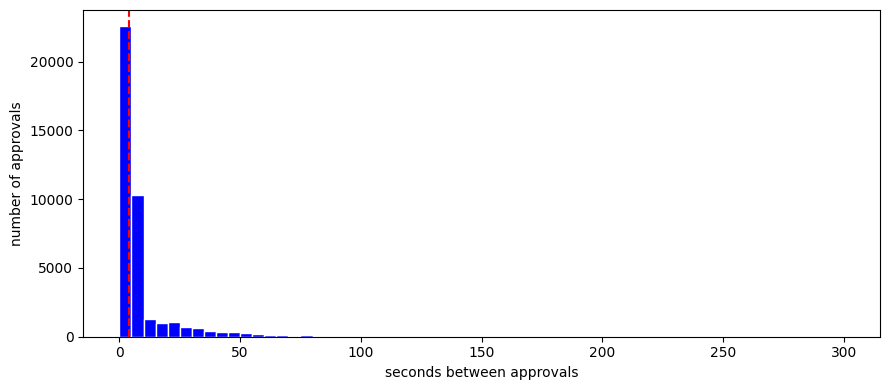

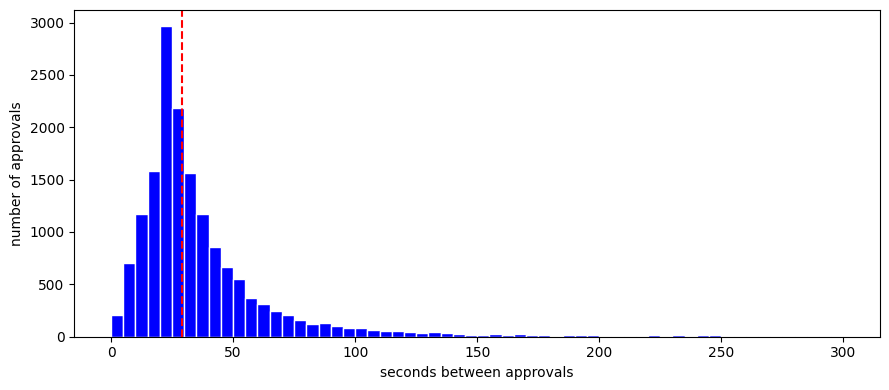

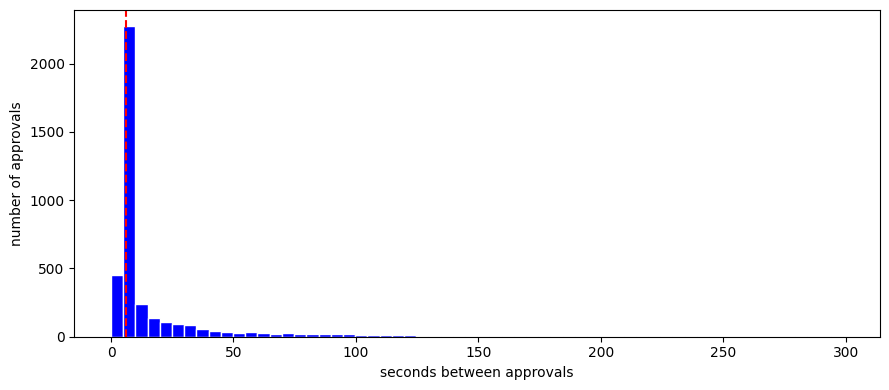

In [15]:
for tech in techs:
  gaps = df.loc[df['Technician'] == tech, 'duration_sameday'].dropna()
  short_gaps = gaps[gaps <= 300]

  plt.hist(short_gaps, bins=60, color='blue', edgecolor= 'white')
  plt.axvline(gaps.median(), color= 'red', linestyle= '--') # Changed 'linestyles' to 'linestyle'
  plt.xlabel('seconds between approvals')
  plt.ylabel('number of approvals')
  plt.tight_layout()
  plt.show()

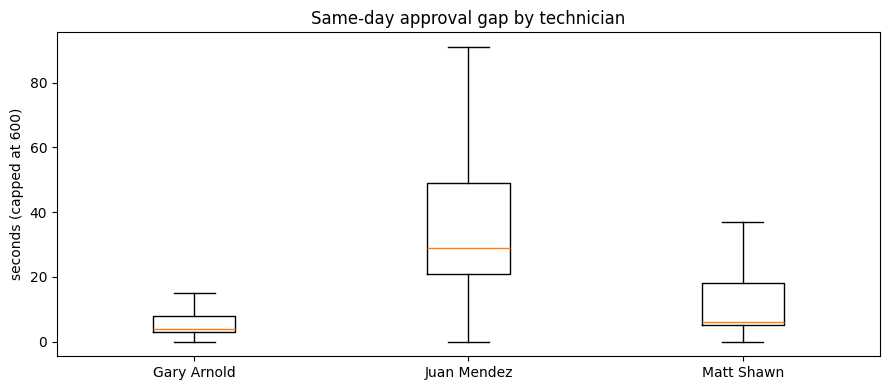

In [16]:
box = []
for tech in techs:
  gaps = df.loc[df['Technician'] == tech, 'duration_sameday'].dropna()
  box.append(gaps.clip(upper=600))

plt.boxplot(box, showfliers=False)
plt.xticks(range(1, len(techs) + 1), techs)
plt.ylabel('seconds (capped at 600)')
plt.title('Same-day approval gap by technician')
plt.tight_layout()
plt.show()

# Same Minute and Same Second

In [17]:
succession_row = []

for tech in techs:
  gaps = df.loc[df['Technician'] == tech, 'duration_sameday'].dropna()
  tech_data = df[df['Technician'] == tech]
  per_hour = tech_data.groupby(tech_data['APPROVAL_DATE'].dt.floor('h')).size()

  succession_row.append({
      'Technician': tech,
      'same second (%)' : round((gaps == 0).mean() *100, 2),
      'within 60 seconds (%)' : round((gaps <= 60).mean() * 100, 2),
      'max approvals in one hour': per_hour.max(),
      'mean approvals per active hour' : round(per_hour.mean(),1)
  })

succession = pd.DataFrame(succession_row).set_index('Technician')
print(succession)

             same second (%)  within 60 seconds (%)  max approvals in one hour  mean approvals per active hour
Technician                                                                                                    
Gary Arnold             0.64                  92.24                        220                            31.8
Juan Mendez             0.08                  81.27                        126                            18.1
Matt Shawn              0.46                  88.01                        155                            25.9


In [18]:
#Busiest single minutes
minutes_per = df.groupby(['Technician', df['APPROVAL_DATE'].dt.floor('min')]).size()
minutes_per = minutes_per.reset_index()
minutes_per.columns = ['Technician', 'minute', 'cases_in_minutes']

for tech in techs:
  tech_mins = minutes_per[minutes_per['Technician'] == tech]
  top = tech_mins.sort_values('cases_in_minutes', ascending = False).head(3)
  print(tech)
  print(top[['minute', 'cases_in_minutes']].to_string(index=False))
  print()

Gary Arnold
             minute  cases_in_minutes
2021-03-11 07:04:00                27
2021-02-04 18:16:00                25
2021-03-03 06:04:00                25

Juan Mendez
             minute  cases_in_minutes
2019-11-14 15:16:00                 6
2019-04-26 07:34:00                 6
2019-03-02 18:53:00                 5

Matt Shawn
             minute  cases_in_minutes
2019-02-02 19:38:00                12
2019-02-14 08:44:00                12
2019-02-20 11:48:00                12



# Daily Approval rate and Time Patterns


In [19]:
#Approval per day
daily = df.groupby(['Technician', 'date', 'payout_period']).size()
daily= daily.reset_index()
daily.columns = ['Technician', 'date', 'payout_period', 'approvals_per_day']

daily_statistics = daily.groupby('Technician')['approvals_per_day'].describe()
print('Approvals per day:')
print(daily_statistics)

Approvals per day:
             count        mean        std  min     25%    50%     75%    max
Technician                                                                  
Gary Arnold  263.0  162.152091  70.466220  5.0  116.50  167.0  208.00  385.0
Juan Mendez  148.0  118.033784  49.309989  3.0   96.00  124.5  153.25  292.0
Matt Shawn    28.0  146.964286  59.599579  2.0  117.25  156.5  180.00  296.0


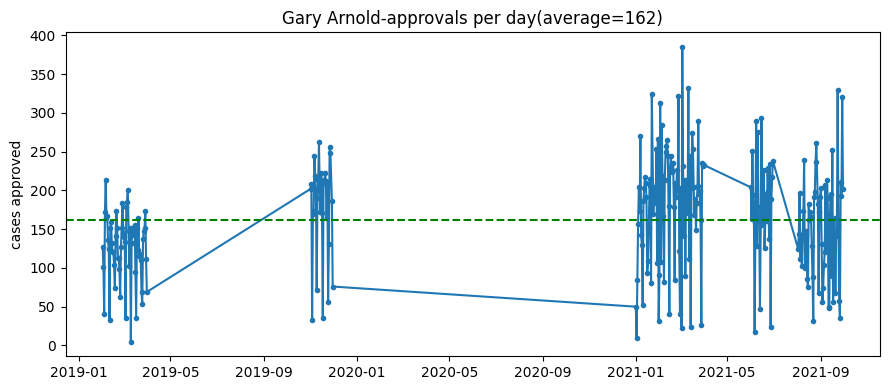

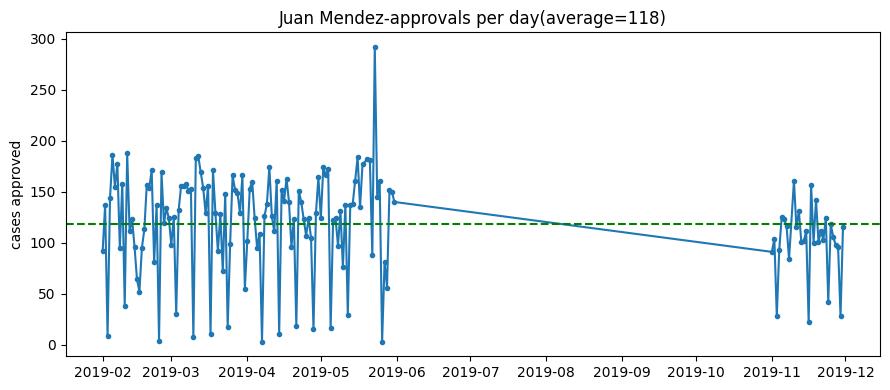

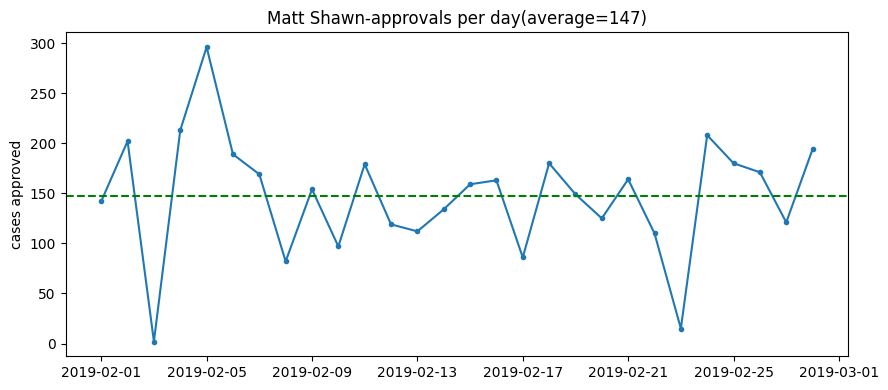

In [20]:
# Daily approval rate over time, one chart per technician
for tech in techs:
  tech_daily = daily[daily['Technician']== tech]
  average = tech_daily['approvals_per_day'].mean()

  plt.plot(pd.to_datetime(tech_daily['date']), tech_daily['approvals_per_day'], marker = '.')
  plt.axhline(average, color = 'green', linestyle='--')
  plt.title( tech + '-approvals per day(average=' + str(round(average)) + ')')
  plt.ylabel('cases approved')
  plt.tight_layout()
  plt.show()

In [21]:
# Top 5 approval days for each technician
for tech in techs:
  tech_daily = daily[daily['Technician']== tech]
  top_days = tech_daily.sort_values('approvals_per_day', ascending= False).head(3)
  print(tech)
  print(top_days[['date', 'approvals_per_day']].to_string(index=False))
  print()

Gary Arnold
      date  approvals_per_day
2021-03-03                385
2021-03-11                332
2021-09-23                329

Juan Mendez
      date  approvals_per_day
2019-05-23                292
2019-02-11                188
2019-02-05                186

Matt Shawn
      date  approvals_per_day
2019-02-05                296
2019-02-04                213
2019-02-24                208



In [22]:
#Off-hours and weekend work
hours_off_data = []

for tech in techs :
  tech_data = df[df['Technician']== tech]
  off_hours = ~tech_data['hour'].between(7,18)
  hours_off_data.append({
      'Technician': tech,
      'outside 7am-7pm (%)' : round (off_hours.mean() * 100, 1),
      'weekend (%)' : round(tech_data['is_weekend'].mean() * 100, 1)
  })

print(pd.DataFrame(hours_off_data).set_index('Technician'))

             outside 7am-7pm (%)  weekend (%)
Technician                                   
Gary Arnold                 27.3         17.3
Juan Mendez                 31.7         20.0
Matt Shawn                  23.6         22.5


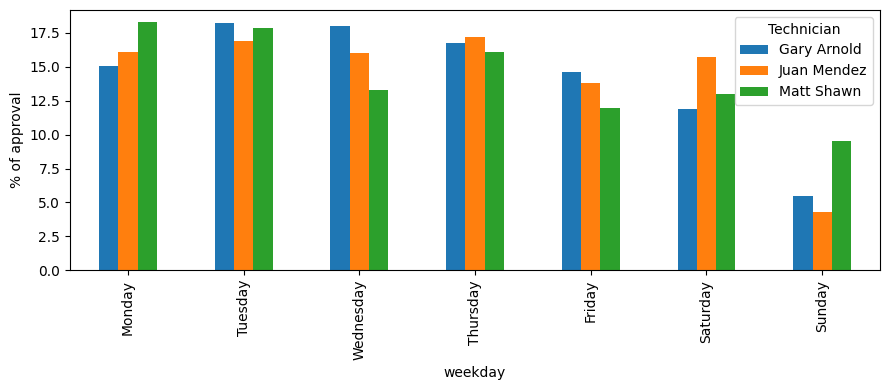

Technician  Gary Arnold  Juan Mendez  Matt Shawn
weekday                                         
Monday             15.1         16.1        18.3
Tuesday            18.2         16.9        17.9
Wednesday          18.0         16.0        13.3
Thursday           16.8         17.2        16.1
Friday             14.6         13.8        12.0
Saturday           11.9         15.7        13.0
Sunday              5.5          4.3         9.6


In [23]:
#Approvals by Weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_table = pd.crosstab(df['weekday'], df['Technician'], normalize='columns') * 100
weekday_table = weekday_table.reindex(day_order)

weekday_table.plot(kind='bar')
plt.ylabel('% of approval')
plt.tight_layout()
plt.show()

print(weekday_table.round(1))

In [24]:
#Monthly mean and median gap - background for the policy change section
monthly = df.groupby(['Technician', 'month'])['duration_sameday'].agg(['count', 'mean', 'median'])
print(monthly.round(1))

                     count   mean  median
Technician  month                        
Gary Arnold 2019-02   3574  260.1     7.0
            2019-03   3802  262.8     5.0
            2019-11   5140  162.1     4.0
            2021-01   4832  192.2     4.0
            2021-02   5420  175.0     4.0
            2021-03   5967  166.9     4.0
            2021-06   5180  153.7     4.0
            2021-08   4190  200.5     5.0
            2021-09   4278  162.3     4.0
Juan Mendez 2019-02   3254  276.7    31.0
            2019-03   3794  275.7    27.0
            2019-04   3453  302.2    29.0
            2019-05   3901  302.1    30.0
            2019-11   2919  311.5    29.0
Matt Shawn  2019-02   4087  250.1     6.0


# Industry Standard

Null hypothesis: mu = mu0--Technician's mean review times equals the industry standard

Alternative hypothesis: mu < mu0--Technician' mean review time is les than industry standard

In [25]:
standard_time = [10, 5, 2, 1]

measures = {
    'Test A -- same-day gaps': 'duration_sameday',
    'Test B -- within_block gaps': 'duration_inblock' # Corrected 'dur_inblock' to 'duration_inblock'
}

t_test = []

for measure_name, column in measures.items():
  for tech in techs:
    gaps= df.loc[df['Technician'] == tech, column].dropna()
    gaps_minutes = gaps / 60

    for standard in standard_time:
      t_stat, p_two_sided = stats.ttest_1samp(gaps_minutes, standard) # Changed standard_time to standard

      #convert to a one-side (left-tailed) p-value
      if t_stat < 0:
        p_one_sided = p_two_sided / 2
      else:
        p_one_sided = 1  - (p_two_sided / 2)

      if p_one_sided < 0.05 and t_stat <0:
        decision = 'Reject H0'
      else:
        decision = 'Fail to reject H0'

      t_test.append({
          'Technician' : tech,
          'Standard (min)' : standard,
          'n' : len(gaps_minutes),
          'Mean (min)': round(gaps_minutes.mean(),2),
          'Median (min)': round(gaps_minutes.median(), 2),
          't-stat': round(t_stat, 2),
          'p (one-sided)' : p_one_sided,
          'Decision': decision
      })

ttest_results = pd.DataFrame(t_test)
print(ttest_results.to_string(index=False))

 Technician  Standard (min)     n  Mean (min)  Median (min)   t-stat  p (one-sided)          Decision
Gary Arnold              10 42383        3.13          0.07   -49.31   0.000000e+00         Reject H0
Gary Arnold               5 42383        3.13          0.07   -13.41   3.221383e-41         Reject H0
Gary Arnold               2 42383        3.13          0.07     8.13   1.000000e+00 Fail to reject H0
Gary Arnold               1 42383        3.13          0.07    15.31   1.000000e+00 Fail to reject H0
Juan Mendez              10 17321        4.89          0.48   -24.16  3.785284e-127         Reject H0
Juan Mendez               5 17321        4.89          0.48    -0.54   2.947048e-01 Fail to reject H0
Juan Mendez               2 17321        4.89          0.48    13.63   1.000000e+00 Fail to reject H0
Juan Mendez               1 17321        4.89          0.48    18.36   1.000000e+00 Fail to reject H0
 Matt Shawn              10  4087        4.17          0.10   -12.34   1.076912e-3

# Batch Approval Claim

In [26]:
#Build one row per block
blocks = df.groupby(['Technician', 'block_id']).agg(
    block_start=('APPROVAL_DATE', 'min'),
    block_end= ('APPROVAL_DATE', 'max'),
    number_cases= ('CASE_NUMBER', 'count')
).reset_index()

#How long the block lasted, and the average time per case inside it
blocks['block_span_seconds'] = (blocks['block_end'] - blocks['block_start']).dt.total_seconds()
blocks['seconds_per_case'] = blocks['block_span_seconds'] / (blocks['number_cases'] - 1)
blocks.loc[blocks['number_cases'] == 1, 'seconds_per_case'] = np.nan

print(blocks.head(10))

    Technician  block_id         block_start           block_end  number_cases  block_span_seconds  seconds_per_case
0  Gary Arnold         1 2019-02-01 10:04:27 2019-02-01 10:22:42            85              1095.0         13.035714
1  Gary Arnold         2 2019-02-01 12:41:53 2019-02-01 12:48:10            28               377.0         13.962963
2  Gary Arnold         3 2019-02-01 13:14:15 2019-02-01 13:16:03             4               108.0         36.000000
3  Gary Arnold         4 2019-02-01 14:24:17 2019-02-01 14:24:17             1                 0.0               NaN
4  Gary Arnold         5 2019-02-01 14:40:06 2019-02-01 14:45:23             6               317.0         63.400000
5  Gary Arnold         6 2019-02-01 17:05:12 2019-02-01 17:06:16             3                64.0         32.000000
6  Gary Arnold         7 2019-02-02 14:47:22 2019-02-02 15:20:56            57              2014.0         35.964286
7  Gary Arnold         8 2019-02-02 17:26:25 2019-02-02 17:33:54

In [27]:
first_of_block = df[df['new_block'] == True][['Technician', 'block_id', 'duration_second']]
first_of_block = first_of_block.rename(columns={'duration_second': 'prep_seconds'})

blocks = blocks.merge(first_of_block, on=['Technician', 'block_id'], how ='left')

blocks['enough_prep_1min'] = blocks['prep_seconds'] >= blocks['number_cases'] * 60
blocks['enough_prep_5min'] = blocks['prep_seconds'] >= blocks['number_cases'] * 60 * 5
blocks['enough_prep_10min'] = blocks['prep_seconds'] >= blocks['number_cases'] * 60 * 10

print(blocks.head())

    Technician  block_id         block_start           block_end  number_cases  block_span_seconds  seconds_per_case  prep_seconds  enough_prep_1min  enough_prep_5min  enough_prep_10min
0  Gary Arnold         1 2019-02-01 10:04:27 2019-02-01 10:22:42            85              1095.0         13.035714           NaN             False             False              False
1  Gary Arnold         2 2019-02-01 12:41:53 2019-02-01 12:48:10            28               377.0         13.962963        8351.0              True             False              False
2  Gary Arnold         3 2019-02-01 13:14:15 2019-02-01 13:16:03             4               108.0         36.000000        1565.0              True              True              False
3  Gary Arnold         4 2019-02-01 14:24:17 2019-02-01 14:24:17             1                 0.0               NaN        4094.0              True              True               True
4  Gary Arnold         5 2019-02-01 14:40:06 2019-02-01 14:45:23      

In [28]:
key_performance_indicator = []

for tech in techs:
  tech_blocks = blocks[blocks['Technician'] == tech]
  tech_gaps_duration = df.loc[df['Technician'] == tech, 'duration_sameday'].dropna() # Store duration gaps separately
  active_days_count = df.loc[df['Technician'] == tech, 'date'].nunique() # Store active days count separately

  key_performance_indicator.append({
      'Technician': tech,
      'number of blocks': len(tech_blocks),
      'mean cases per block': round(tech_blocks['number_cases'].mean(), 1),
      'median case per block': tech_blocks['number_cases'].median(),
      'max cases in one block': tech_blocks['number_cases'].max(),
      'mean seconds per case in block': round(tech_blocks['seconds_per_case'].mean(),1),
      'blocks per active day': round(len(tech_blocks)/ active_days_count, 2),
      'fast approval ratio under 10s (%)': round((tech_gaps_duration < 10).mean()*100, 1),
      'prep covers 1 min per case (%)': round(tech_blocks['enough_prep_1min'].mean() * 100, 1),
      'prep covers 5 min per case (%)': round(tech_blocks['enough_prep_5min'].mean() * 100, 1),
      'prep covers 10 min per case (%)': round(tech_blocks['enough_prep_10min'].mean() * 100, 1)
  })

  kpi = pd.DataFrame(key_performance_indicator).set_index('Technician')
  print(kpi.T)

Technician                         Gary Arnold
number of blocks                       1556.00
mean cases per block                     27.40
median case per block                    11.00
max cases in one block                  233.00
mean seconds per case in block           20.30
blocks per active day                     5.92
fast approval ratio under 10s (%)        77.70
prep covers 1 min per case (%)           93.40
prep covers 5 min per case (%)           71.50
prep covers 10 min per case (%)          34.80
Technician                         Gary Arnold  Juan Mendez
number of blocks                       1556.00      1076.00
mean cases per block                     27.40        16.20
median case per block                    11.00         6.50
max cases in one block                  233.00       177.00
mean seconds per case in block           20.30        57.30
blocks per active day                     5.92         7.27
fast approval ratio under 10s (%)        77.70         5.20
pre

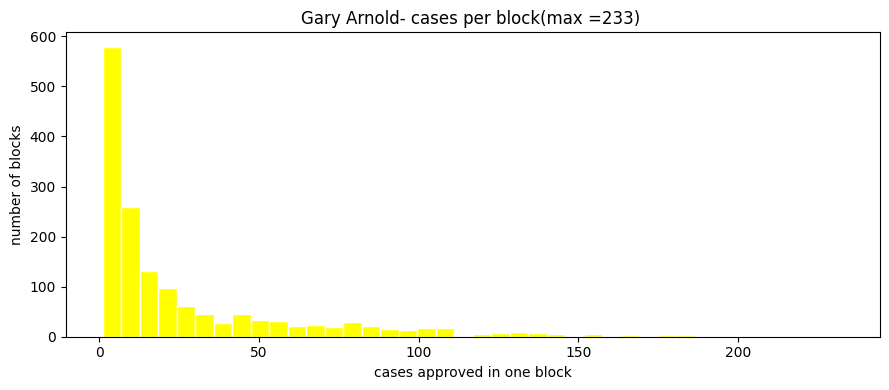

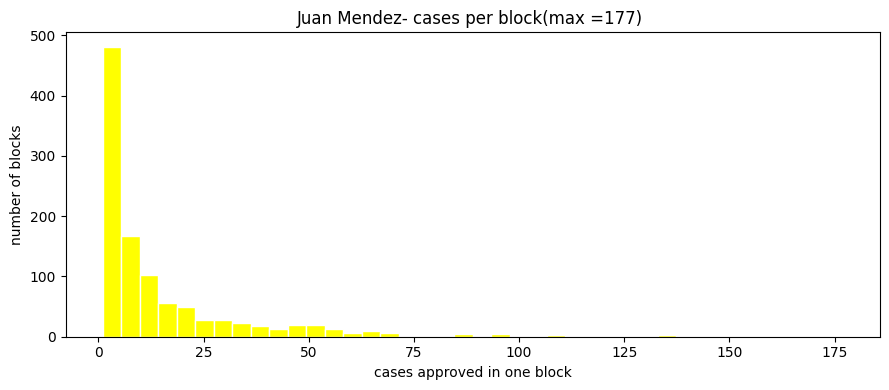

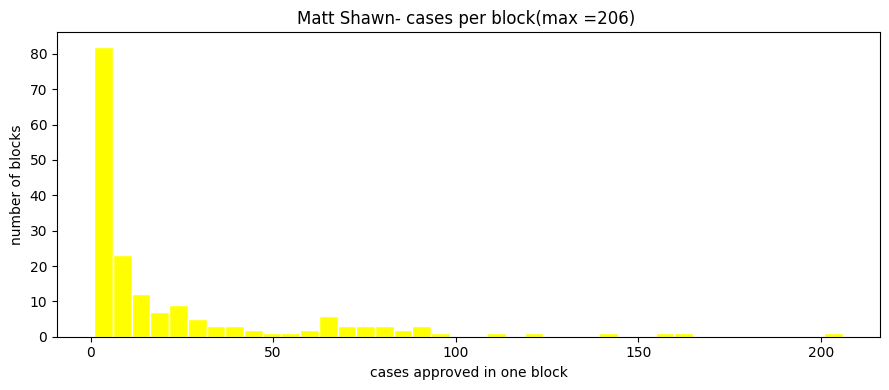

In [29]:
#How many cases are approved per session?

for tech in techs:
  tech_blocks = blocks[blocks['Technician'] == tech]
  plt.hist(tech_blocks['number_cases'] , bins=40, color='yellow', edgecolor= 'white')
  plt.title(tech + '- cases per block(max =' + str(tech_blocks['number_cases'].max()) + ') ')
  plt.xlabel('cases approved in one block')
  plt.ylabel('number of blocks')
  plt.tight_layout()
  plt.show()

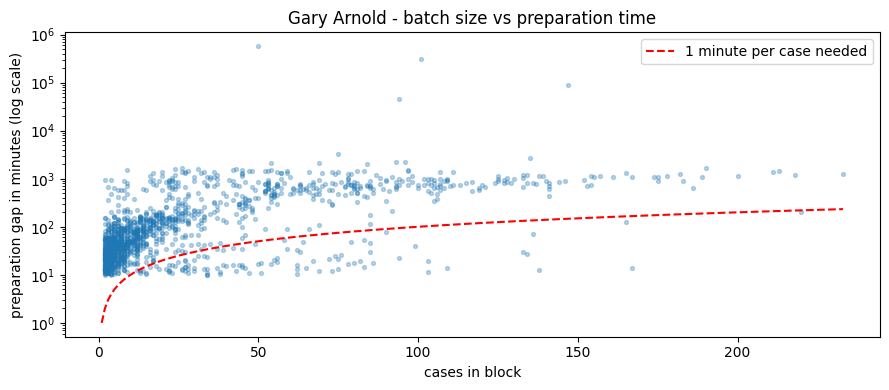

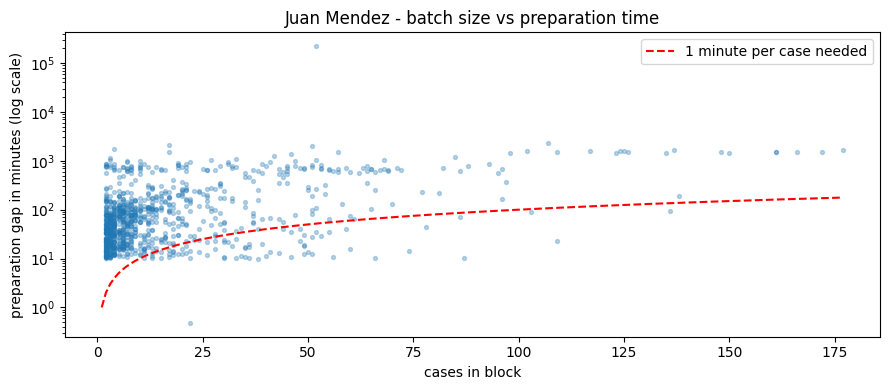

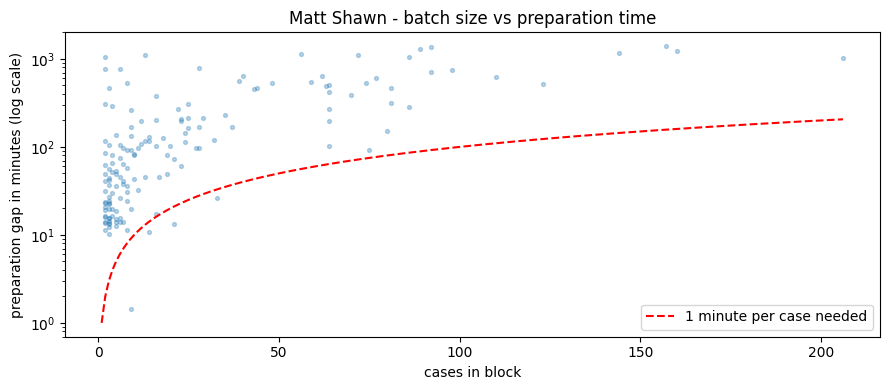

In [30]:
for tech in techs:
  tech_blocks = blocks[(blocks['Technician'] == tech) &
                       (blocks['number_cases'] > 1) &
                       (blocks['prep_seconds'].notnull())]

  if not tech_blocks.empty:
    plt.scatter(tech_blocks['number_cases'], tech_blocks['prep_seconds'] / 60, s=8, alpha =0.3)
    # Ensure the max value is not NaN before passing to arange
    max_cases = tech_blocks['number_cases'].max()
    if pd.notnull(max_cases):
      x_line = np.arange(1, int(max_cases) + 1)
      plt.plot(x_line, x_line, 'r--', label='1 minute per case needed')
    plt.yscale('log')
    plt.xlabel('cases in block')
    plt.ylabel('preparation gap in minutes (log scale)')
    plt.title(tech + ' - batch size vs preparation time')
    plt.legend()
    plt.tight_layout()
    plt.show()
  else:
    print(f"No data for {tech} after filtering to plot scatter plot.")

In [31]:
for tech in techs:
    tech_blocks = blocks[(blocks['Technician'] == tech) &
                         (blocks['number_cases'] > 1) &
                         (blocks['prep_seconds'].notnull())]


    print(f"Processed blocks for {tech}: {len(tech_blocks)}")

Processed blocks for Gary Arnold: 1436
Processed blocks for Juan Mendez: 914
Processed blocks for Matt Shawn: 152


# Payout Policy

In [32]:
print(pd.crosstab(df['Technician'], df['payout_period']))
print()
print('Only Gary Arnold has data before AND after June 2020.')
print('Mendez stops in Nov 2019 and Shawn only has Feb 2019,')
print('so the before/after test cannot be run for them.')

payout_period  Post-June2020 ($17)  Pre-June2020 ($50)
Technician                                            
Gary Arnold                  30042               12604
Juan Mendez                      0               17469
Matt Shawn                       0                4115

Only Gary Arnold has data before AND after June 2020.
Mendez stops in Nov 2019 and Shawn only has Feb 2019,
so the before/after test cannot be run for them.


In [39]:
policy = []

for tech in techs:
    tech_data = df[df['Technician'] == tech]
    before = tech_data.loc[tech_data['payout_period'] == 'Pre-Jun2020 ($50)', 'duration_sameday'].dropna()
    after = tech_data.loc[tech_data['payout_period'] == 'Post-Jun2020 ($17)', 'duration_sameday'].dropna()

    row = {'Technician': tech, 'n before': len(before), 'n after': len(after)}

    if len(before) > 1 and len(after) > 1:
        t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)

        row['mean before (s)'] = round(before.mean(), 1)
        row['mean after (s)'] = round(after.mean(), 1)
        row['median before (s)'] = before.median()
        row['median after (s)'] = after.median()
        row['under 10s before (%)'] = round((before < 10).mean() * 100, 1)
        row['under 10s after (%)'] = round((after < 10).mean() * 100, 1)
        row['t-stat'] = round(t_stat, 2)
        row['p-value'] = round(p_value, 4)
        row['Decision'] = 'Reject H0' if p_value < 0.05 else 'Fail to reject H0'
    else:
        row['Decision'] = 'Cannot test - no data after June 2020'

    policy.append(row)

policy_test = pd.DataFrame(policy).set_index('Technician')
print(policy_test.T)

Technician                            Gary Arnold                            Juan Mendez                             Matt Shawn
n before                                        0                                      0                                      0
n after                                         0                                      0                                      0
Decision    Cannot test - no data after June 2020  Cannot test - no data after June 2020  Cannot test - no data after June 2020


In [34]:
# Did the daily approval RATE change?
# H0: mean approvals per day is the same before and after
for tech in techs:
    tech_daily = daily[daily['Technician'] == tech]
    before = tech_daily.loc[tech_daily['payout_period'] == 'Pre-Jun2020 ($50)', 'approvals_per_day']
    after = tech_daily.loc[tech_daily['payout_period'] == 'Post-Jun2020 ($17)', 'approvals_per_day']

    if len(before) > 1 and len(after) > 1:
        t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)
        print(tech, '- before:', round(before.mean(), 1), 'per day |',
              'after:', round(after.mean(), 1), 'per day |',
              't =', round(t_stat, 2), '| p =', round(p_value, 5))
    else:
        print(tech, '- cannot test, no data after June 2020')

Gary Arnold - cannot test, no data after June 2020
Juan Mendez - cannot test, no data after June 2020
Matt Shawn - cannot test, no data after June 2020


/usr/local/lib/python3.13/dist-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


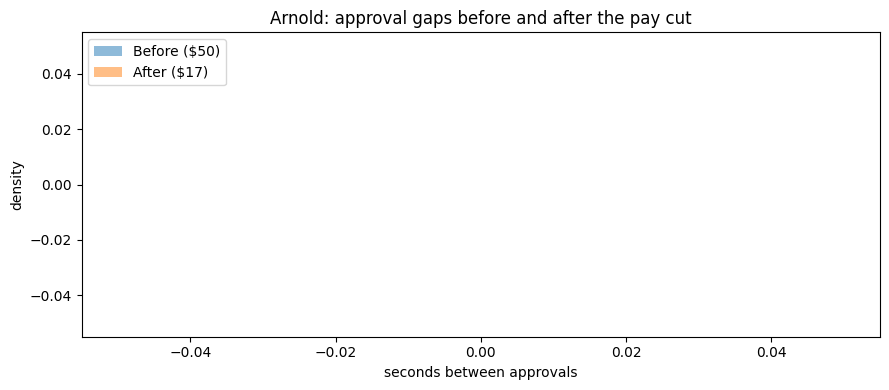

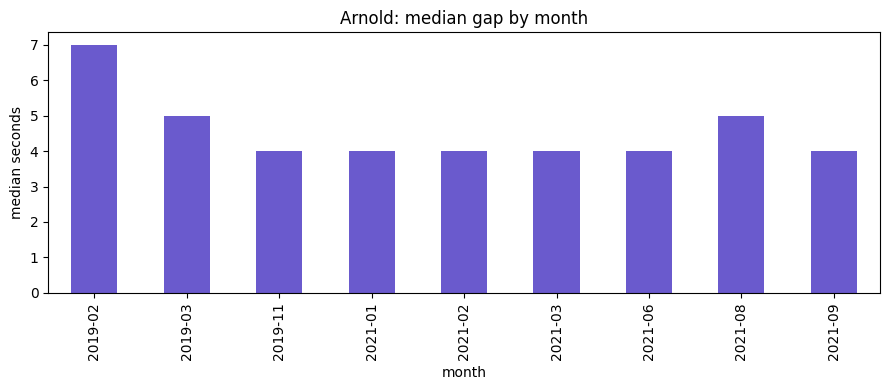

In [36]:
# Arnold before vs after the pay cut
arnold = df[df['Technician'] == 'Gary Arnold']

before = arnold.loc[arnold['payout_period'] == 'Pre-Jun2020 ($50)', 'duration_sameday'].dropna()
after = arnold.loc[arnold['payout_period'] == 'Post-Jun2020 ($17)', 'duration_sameday'].dropna()

plt.hist(before[before <= 120], bins=60, alpha=0.5, label='Before ($50)', density=True)
plt.hist(after[after <= 120], bins=60, alpha=0.5, label='After ($17)', density=True)
plt.xlabel('seconds between approvals')
plt.ylabel('density')
plt.title('Arnold: approval gaps before and after the pay cut')
plt.legend()
plt.tight_layout()
plt.show()

monthly_median = arnold.groupby('month')['duration_sameday'].median()
monthly_median.plot(kind='bar', color='slateblue')
plt.ylabel('median seconds')
plt.title('Arnold: median gap by month')
plt.tight_layout()
plt.show()

# Dashboard

In [37]:
!pip install -q gradio plotly pandas scipy

In [38]:
import gradio as gr
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

techs = sorted(df['Technician'].unique())
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
review_thresholds = [0, 2, 5, 10, 30, 60]
standard_time = [10, 5, 2, 1]
measures = {'Test A -- same-day gaps': 'duration_sameday',
            'Test B -- within-block gaps': 'duration_inblock'}

def make_dashboard(tech):
    t_df = df[df['Technician'] == tech]
    t_daily = daily[daily['Technician'] == tech]
    t_blocks = blocks[blocks['Technician'] == tech]
    gaps_sameday = t_df['duration_sameday'].dropna()

    # 1. Approvals per day over time
    fig_daily = px.line(t_daily.sort_values('date'), x='date', y='approvals_per_day',
                         markers=True, title='Approvals per day')
    fig_daily.add_hline(y=t_daily['approvals_per_day'].mean(), line_dash='dash', line_color='green')

    # 2. Fast-approval thresholds
    fast_row = {f'{t}s or less (%)': round((gaps_sameday <= t).mean() * 100, 2) for t in review_thresholds}
    fig_fast = px.bar(x=list(fast_row.keys()), y=list(fast_row.values()), title='Fast-approval thresholds',
                       labels={'x': 'threshold', 'y': '% of approvals'})

    # 3. Skewness / mean vs median table
    skew_df = pd.DataFrame([{
        'skewness': round(gaps_sameday.skew(), 2) if len(gaps_sameday) > 2 else None,
        'mean_seconds': round(gaps_sameday.mean(), 2),
        'median_seconds': round(gaps_sameday.median(), 2),
        'mean_div_median': round(gaps_sameday.mean() / gaps_sameday.median(), 2) if gaps_sameday.median() else None
    }])

    # 4. Boxplot across all technicians (selected one highlighted by order)
    fig_box = go.Figure()
    for tc in techs:
        g = df.loc[df['Technician'] == tc, 'duration_sameday'].dropna().clip(upper=600)
        fig_box.add_trace(go.Box(y=g, name=tc, marker_color='crimson' if tc == tech else 'lightgray'))
    fig_box.update_layout(title='Same-day gap by technician (capped at 600s)')

    # 5. Short-gap histogram with median line
    short_gaps = gaps_sameday[gaps_sameday <= 300]
    fig_hist = px.histogram(short_gaps, nbins=60, title='Short gaps (<=300s)',
                             labels={'value': 'seconds'})
    fig_hist.add_vline(x=gaps_sameday.median(), line_dash='dash', line_color='red')

    # 6. Same-second / succession stats
    per_hour = t_df.groupby(t_df['APPROVAL_DATE'].dt.floor('h')).size()
    succession_df = pd.DataFrame([{
        'same second (%)': round((gaps_sameday == 0).mean() * 100, 2),
        'within 60 sec (%)': round((gaps_sameday <= 60).mean() * 100, 2),
        'max approvals in one hour': int(per_hour.max()) if len(per_hour) else 0,
        'mean approvals per active hour': round(per_hour.mean(), 2) if len(per_hour) else 0
    }])

    # 7. Busiest minutes
    minutes_per = t_df.groupby(t_df['APPROVAL_DATE'].dt.floor('min')).size().reset_index()
    minutes_per.columns = ['minute', 'cases_in_minute']
    top_minutes = minutes_per.sort_values('cases_in_minute', ascending=False).head(5)

    # 8. Weekday distribution
    wk = t_df['weekday'].value_counts(normalize=True).reindex(day_order).fillna(0) * 100
    fig_weekday = px.bar(x=wk.index, y=wk.values, title='Approvals by weekday',
                          labels={'x': 'weekday', 'y': '% of approvals'})

    # 9. Off-hours / weekend
    off_hours = (~t_df['hour'].between(7, 18)).mean() * 100
    weekend = t_df['is_weekend'].mean() * 100
    fig_offhours = go.Figure(go.Bar(x=['Outside 7am-7pm', 'Weekend'], y=[off_hours, weekend]))
    fig_offhours.update_layout(title='Off-hours and weekend activity (%)')

    # 10. Monthly mean/median gap
    monthly = t_df.groupby('month')['duration_sameday'].agg(['count', 'mean', 'median']).round(1).reset_index()

    # 11. t-tests vs industry standard
    t_rows = []
    for measure_name, col in measures.items():
        gaps = t_df[col].dropna()
        if len(gaps) > 1:
            gaps_minutes = gaps / 60
            for standard in standard_time:
                t_stat, p_two = stats.ttest_1samp(gaps_minutes, standard)
                p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2
                t_rows.append({'test': measure_name, 'standard_min': standard,
                                'mean_min': round(gaps_minutes.mean(), 2),
                                't_stat': round(t_stat, 2), 'p_one_sided': round(p_one, 4)})
    ttest_df = pd.DataFrame(t_rows)

    # 12. Block KPIs
    kpi_df = pd.DataFrame([{
        'number_of_blocks': len(t_blocks),
        'mean_cases_per_block': round(t_blocks['number_cases'].mean(), 2) if len(t_blocks) else 0,
        'active_days': t_df['date'].nunique(),
        'mean_gap_sec': round(gaps_sameday.mean(), 2) if len(gaps_sameday) else None,
        'median_gap_sec': round(gaps_sameday.median(), 2) if len(gaps_sameday) else None
    }])

    # 13. Cases per block
    fig_blocks_hist = px.histogram(t_blocks, x='number_cases', nbins=40, title='Cases per approval block')

    # 14. Cases vs prep time scatter
    scatter_data = t_blocks[(t_blocks['number_cases'] > 1) & (t_blocks['prep_seconds'].notnull())]
    if not scatter_data.empty:
        fig_scatter = px.scatter(scatter_data, x='number_cases', y=scatter_data['prep_seconds'] / 60,
                                  title='Prep time (min) vs cases in block',
                                  labels={'y': 'prep minutes'})
    else:
        fig_scatter = go.Figure()
        fig_scatter.update_layout(title='No block data with prep time for this technician')

    # 15. Payout policy before/after
    if 'payout_period' in t_df.columns:
        before = t_df.loc[t_df['payout_period'] == 'Pre-Jun2020 ($50)', 'duration_sameday'].dropna()
        after = t_df.loc[t_df['payout_period'] == 'Post-Jun2020 ($17)', 'duration_sameday'].dropna()
        if len(before) > 1 and len(after) > 1:
            fig_payout = go.Figure()
            fig_payout.add_trace(go.Histogram(x=before[before <= 120], name='Before ($50)',
                                               opacity=0.5, histnorm='probability density'))
            fig_payout.add_trace(go.Histogram(x=after[after <= 120], name='After ($17)',
                                               opacity=0.5, histnorm='probability density'))
            fig_payout.update_layout(barmode='overlay', title='Gap distribution: before vs after pay cut')
            t_stat, p_val = stats.ttest_ind(before, after, equal_var=False)
            payout_text = f"t = {t_stat:.2f}, p = {p_val:.4f} (n_before={len(before)}, n_after={len(after)})"
        else:
            fig_payout = go.Figure()
            fig_payout.update_layout(title='Not enough before/after data for this technician')
            payout_text = "Not enough before/after data for this technician."
    else:
        fig_payout = go.Figure()
        payout_text = "No payout_period column found."

    return (fig_daily, fig_weekday, fig_offhours, fig_fast, fig_hist, fig_box,
            skew_df, succession_df, top_minutes, monthly,
            kpi_df, fig_blocks_hist, fig_scatter, ttest_df, fig_payout, payout_text)

with gr.Blocks(title="Technician Dashboard") as demo:
    gr.Markdown("# ClearCheck Technician Approval Dashboard")
    tech_dropdown = gr.Dropdown(choices=techs, value=techs[0], label="Technician")

    with gr.Tabs():
        with gr.Tab("Volume & Timing"):
            plot_daily = gr.Plot()
            plot_weekday = gr.Plot()
            plot_offhours = gr.Plot()
        with gr.Tab("Gap Analysis"):
            plot_fast = gr.Plot()
            plot_hist = gr.Plot()
            plot_box = gr.Plot()
            table_skew = gr.Dataframe(label="Skewness / mean vs median")
            table_succession = gr.Dataframe(label="Succession stats")
            table_minutes = gr.Dataframe(label="Busiest minutes")
            table_monthly = gr.Dataframe(label="Monthly mean/median gap")
        with gr.Tab("Blocks & KPIs"):
            table_kpi = gr.Dataframe(label="Block KPIs")
            plot_blocks_hist = gr.Plot()
            plot_scatter = gr.Plot()
        with gr.Tab("Statistical Tests"):
            table_ttest = gr.Dataframe(label="One-sample t-tests vs industry standard")
        with gr.Tab("Payout Policy"):
            plot_payout = gr.Plot()
            text_payout = gr.Textbox(label="Two-sample t-test result")

    outputs = [plot_daily, plot_weekday, plot_offhours, plot_fast, plot_hist, plot_box,
               table_skew, table_succession, table_minutes, table_monthly,
               table_kpi, plot_blocks_hist, plot_scatter, table_ttest, plot_payout, text_payout]

    tech_dropdown.change(fn=make_dashboard, inputs=tech_dropdown, outputs=outputs)
    demo.load(fn=make_dashboard, inputs=tech_dropdown, outputs=outputs)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45d0f1d4d66e7ffff0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
